In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, sklearn, re, pickle, json, joblib, glob
import plotly.graph_objects as go, tkinter as tk, shap
import seaborn as sn
from tkinter import filedialog
from operator import attrgetter
from collections import Counter

from sklearn import metrics, set_config
from sklearn.metrics import make_scorer, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm.sklearn import LGBMClassifier
from xgboost import XGBClassifier

from fairml import audit_model, plot_dependencies

%matplotlib inline

# Control params
is_test = False
saved_model_name = r"clf.pkl"

# Load data
wd = r"C:\Code\EdwardFryDataScienceChallenge\Challenge2"
dataSourceFilename = r"EdwardFry_Microsoft_issueDataset.csv"

root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title = r"Choose Data Science Challenge Dataset", 
                                       initialdir = wd, initialfile = dataSourceFilename, 
                                       filetypes = [("Comma Delimited", "*.csv")])
df = pd.read_csv(file_path)
df.head()

,Current Evaluation Model of Likelihood to Leave,EmployeeLeft,Hired through SMTP,Marked for PHT Program,Religion (code),Salary,"Survey, Relative, Attitude toward Manager","Survey, Relative, Attitude toward Peers","Survey, Relative, Peer's Average Attitude toward Manager","Survey, Relative, Peer's Average Attitude toward WorkType",University,Weekly Hours Worked
0,1.1,0.0,0,1,0,52751.21,1,5,2,7,Cape Peninsula University of Technology,33
1,2.1,0.0,1,1,3,49532.41,2,5,2,2,Franciscan University of Steubenville,33
2,3.1,1.0,0,0,5,49663.38,2,2,3,3,Yaroslavl International University of Business...,30
3,9.2,0.0,0,0,1,50443.31,5,4,1,2,Tamil Nadu Agricultural University,30
4,1.3,1.0,1,1,2,46130.38,2,3,1,3,Tamil Nadu Agricultural University,30


In [4]:
# Functions
def print_heading(txt, nl = True):
    if nl:
        print('\n')
    print(txt)
    print(len(txt) * "=")
    
def show_missing(df): 
    print_heading("Number of missing values by column")
    
    missing = False
    for i in df.columns:
        if df.loc[df[i].isna(), i].shape[0] > 0:
            missing = True
            print(i, df.loc[df[i].isna(), i].shape)
    
    if not missing:
        print("No missing values")
            
def find_outliers(col):
    outliers = []
    ql = col.quantile(.1)
    qh = col.quantile(.9)
    iqr = qh - ql
    
    lower_limit = ql - (1.5*iqr)
    upper_limit = qh + (1.5*iqr)
    
    for val in col:
        if val > upper_limit or val < lower_limit:
            outliers.append(val)
            
    return np.array(outliers)

def show_outlier_count(df, f):
    print_heading("Number of outliers by column")
    
    for col in df.columns:
        if col in f:
            outliers = find_outliers(df[col])
            if len(outliers) > 0:
                print(f"{col}: {len(outliers)}")   
                
def plot_feature_stats(col):
    fix, (ax1, ax2) = plt.subplots(1, 2, figsize = (7, 5))
    sn.boxplot(y = col, orient = 'v', ax = ax1)
    ax1.set_ylabel = col.name
    ax1.set_title(f"Box plot")
    sn.histplot(col, ax = ax2)
    ax2.set_title(f"Distribution plot")
    
def plot_cat_stats(df, col):
    plot = sn.catplot(x = col.name, data = df, kind = 'count')
    plot.set_xticklabels(rotation = 90)
    
def show_stats_plots(df, f):
    print_heading("Feature basic stats")
    
    for col in df.columns:
        if col in f:
            plot_feature_stats(df[col])
        else:
            plot_cat_stats(df, df[col])
            
def show_basic_eda(df):
    print(f"Shape: {df.shape}")
    #print(f"Number of duplicates: {len(df[df.duplicated()])}\n")  # Check for duplicates (should be 0)
    df.info()  # Basic info

    # Unique values
    print_heading("Unique values")

    for name, data in df.iteritems():
        try:
            unique = pd.unique(data.values)
            print(f"{name} unique values ({len(unique)}): {np.sort(unique)}")
        except Exception as e:
            print(f"Error: {e}")
        
    df.describe()

In [5]:
# EDA
show_basic_eda(df)

Shape: (99000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99000 entries, 0 to 98999
Data columns (total 12 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Current Evaluation Model of Likelihood to Leave            99000 non-null  float64
 1   EmployeeLeft                                               99000 non-null  float64
 2   Hired through SMTP                                         99000 non-null  int64  
 3   Marked for PHT Program                                     99000 non-null  int64  
 4   Religion (code)                                            99000 non-null  int64  
 5   Salary                                                     99000 non-null  float64
 6   Survey, Relative, Attitude toward Manager                  99000 non-null  int64  
 7   Survey, Relative, Attitude toward Peers                    99000 non-null  

In [6]:
# Feature types determined by above examination
categorical_features = ["Hired through SMTP", "Marked for PHT Program", "Religion (code)",
                        "Survey, Relative, Attitude toward Manager",
                        "Survey, Relative, Attitude toward Peers",
                        "Survey, Relative, Peer's Average Attitude toward Manager",
                        "Survey, Relative, Peer's Average Attitude toward WorkType",
                        "University"]
    
numeric_features = ["Current Evaluation Model of Likelihood to Leave", "Salary", "Weekly Hours Worked"]

all_features = categorical_features + numeric_features

target = "EmployeeLeft"
df[target] = pd.Categorical(df[target])



Number of outliers by column
Current Evaluation Model of Likelihood to Leave: 598
Salary: 62
Weekly Hours Worked: 5




Number of missing values by column
No missing values




Feature basic stats


Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.


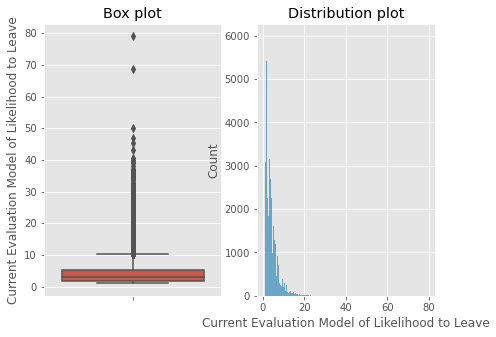

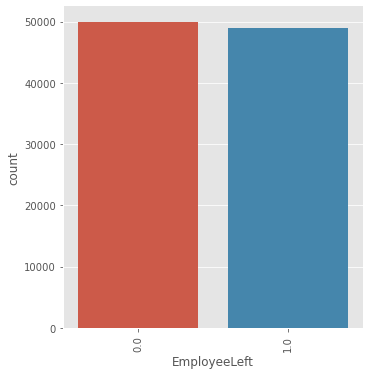

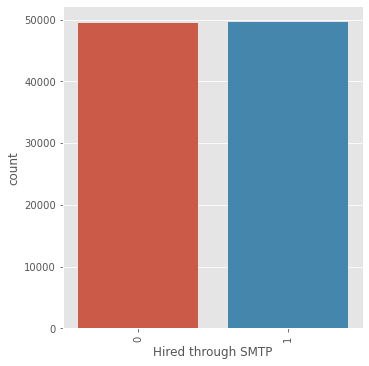

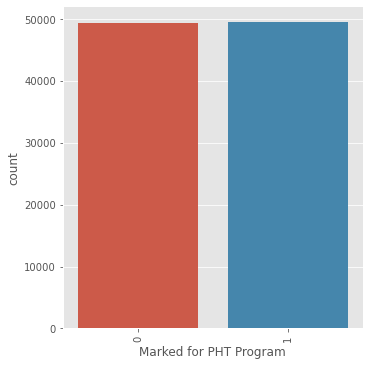

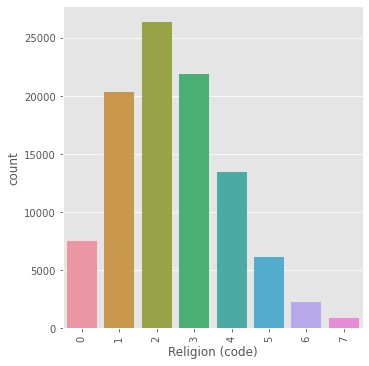

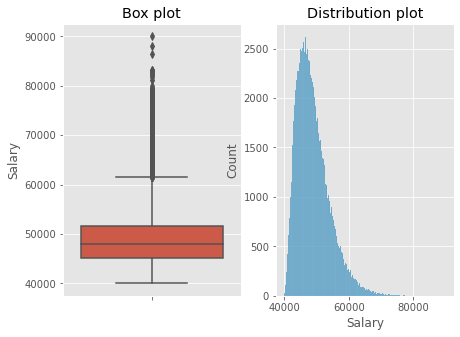

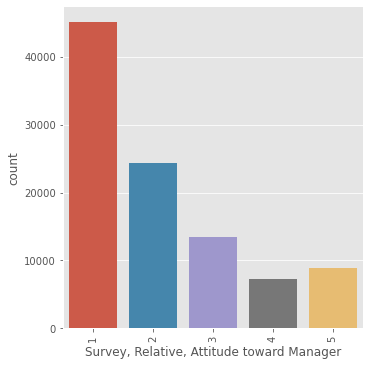

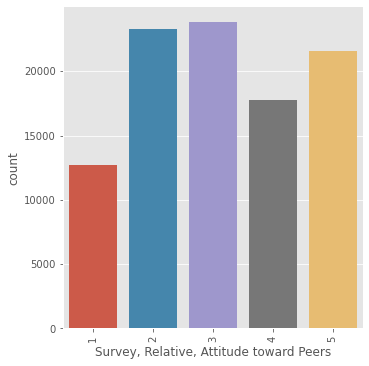

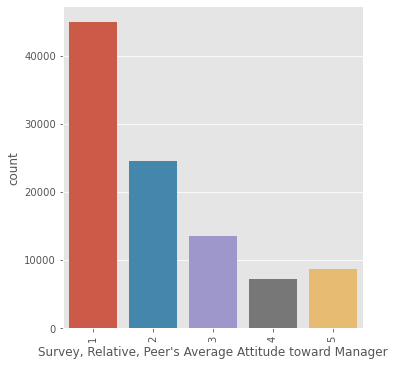

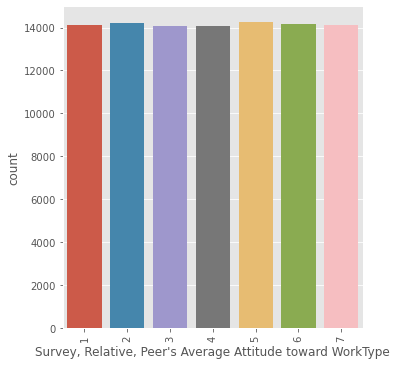

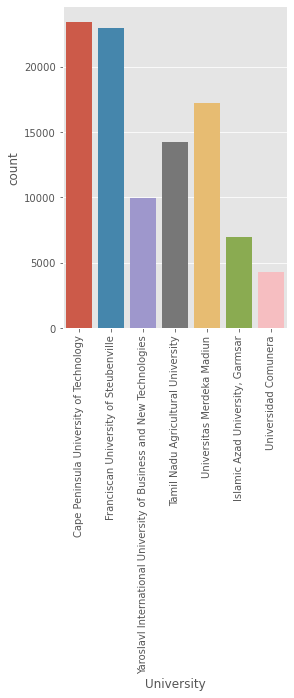

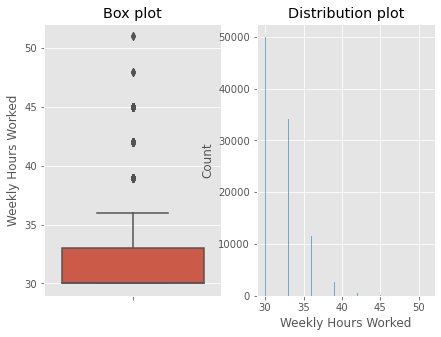

In [7]:
# More EDA
show_outlier_count(df, numeric_features)
print('\n')
show_missing(df)
print('\n')
show_stats_plots(df, numeric_features)



Correlations


<AxesSubplot:>

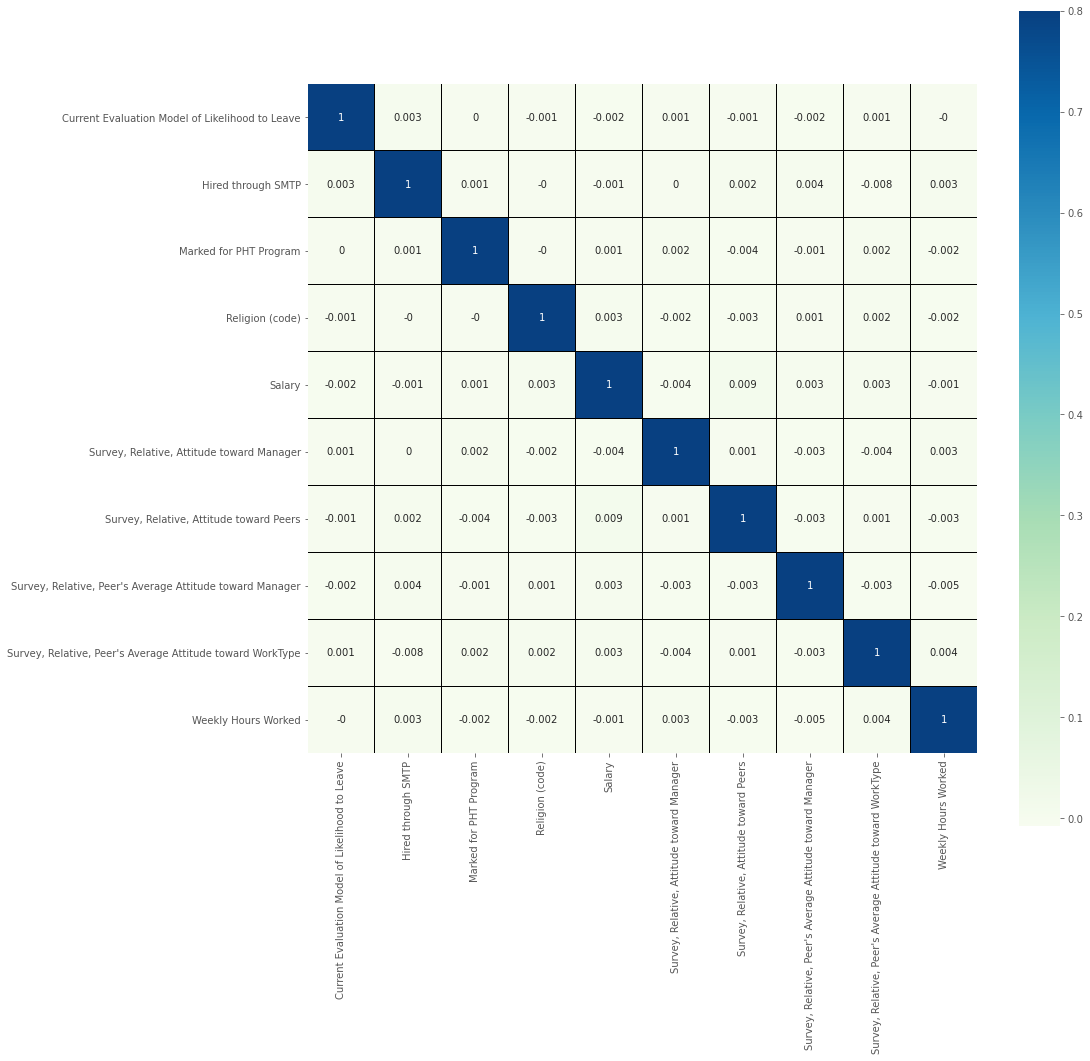

In [8]:
# Correlations
print_heading("Correlations")
corr = round(df.corr(method = 'spearman'), 3)
plt.figure(figsize = (15, 15))
sn.heatmap(corr, vmax = .8, linewidths = .01, square = True, annot = True, cmap = "GnBu", linecolor = 'black')



Variable interactions


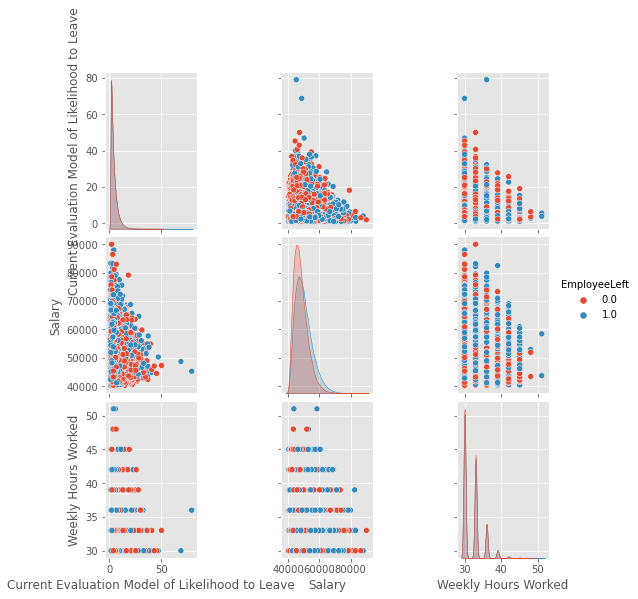

In [9]:
# Variable interactions
for feature in categorical_features:   # Make sure pandas type is correct
    df[feature] = pd.Categorical(df[feature])

# Split features from target
X = df[all_features]
y = df[target]    
    
print_heading("Variable interactions")    
sn.pairplot(data = df, hue = 'EmployeeLeft')

In [10]:
# Data cleanup and pipeline creation
show_basic_eda(X)
numeric_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.nan, strategy = 'median')),
                                        ('scalar', StandardScaler())])

categorical_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
                                            ('ohe', OneHotEncoder(handle_unknown = 'ignore'))])

preprocessor = ColumnTransformer(transformers = [('num', numeric_transformer, numeric_features),
                                                 ('cat', categorical_transformer, categorical_features)],
                                 remainder = 'passthrough')

#Xt = pd.DataFrame(preprocessor.fit_transform(X))
#show_basic_eda(Xt)

Shape: (99000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99000 entries, 0 to 98999
Data columns (total 11 columns):
 #   Column                                                     Non-Null Count  Dtype   
---  ------                                                     --------------  -----   
 0   Hired through SMTP                                         99000 non-null  category
 1   Marked for PHT Program                                     99000 non-null  category
 2   Religion (code)                                            99000 non-null  category
 3   Survey, Relative, Attitude toward Manager                  99000 non-null  category
 4   Survey, Relative, Attitude toward Peers                    99000 non-null  category
 5   Survey, Relative, Peer's Average Attitude toward Manager   99000 non-null  category
 6   Survey, Relative, Peer's Average Attitude toward WorkType  99000 non-null  category
 7   University                                                 99000 n

In [11]:
# Classifier setup
clf = Pipeline(steps = [('preprocessor', preprocessor), 
                        ('classifier', LogisticRegression())])  # Will be replaced later via grid search

In [12]:
# Parameter search
param_grid = [
    {
        "classifier__penalty"              : ['l1', 'l2', 'elasticnet', 'none'],
        "classifier__fit_intercept"        : [False],  # Data should already be normalized
        "classifier__solver"               : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
        "classifier__l1_ratio"             : [0.0, 0.2, 0.6, 1.0],
        "classifier__C"                    : [0.1, 1.0, 10.0, 100.0],
        "classifier": [LogisticRegression()]
    },
    {
        "classifier__n_estimators"        : [50],
        "classifier__max_features"        : ["sqrt", "log2"],
        "classifier__bootstrap"           : [False, True],
        "classifier__criterion"           : ['gini', 'entropy'],
        "classifier__oob_score"           : [True, False],
        "classifier__max_depth"           : [None, 6, 10],
        "classifier__max_leaf_nodes"      : [None, 5, 10],
        "classifier__min_impurity_split"  : [0.1, 0.3],
        "classifier": [RandomForestClassifier()]
    },
    { 
        "classifier__C"                     : [0.001, 0.1, 1, 10, 100, 10e5],
        "classifier__class_weight"          : ['balanced'],
        "classifier__penalty"               : ['l1', 'l2'],
        "classifier__loss"                  : ['hinge', 'squared_hinge'],
        "classifier__fit_intercept"         : [False], # Data should already be normalized
        "classifier": [LinearSVC()]
    },
    { 
        "classifier__boosting"               : ['gbdt', 'rf', 'dart', 'goss'],
        "classifier__max_depth"              : range (2, 10, 1),
        "classifier__learning_rate"          : [0.1, 0.01, 0.05],
        "classifier": [LGBMClassifier()]
    },
    { 
        "classifier__max_depth"              : range (2, 10, 1),
        "classifier__n_estimators"           : range(60, 220, 40),
        "classifier__learning_rate"          : [0.1, 0.01, 0.05],
        "classifier": [XGBClassifier(use_label_encoder=False)]
    },
    { 
        "classifier__alpha"                  : [0.001, 0.1, 1, 10, 100],
        "classifier__activation"             : ['identity', 'logistic', 'tanh', 'relu'],
        "classifier__solver"                 : ['lbfgs', 'sgd', 'adam'],
        "classifier__learning_rate"          : ['constant', 'invscaling', 'adaptive'],
        "classifier__early_stopping"         : [True],
        "classifier": [MLPClassifier()]
    }
]

small_grid = [
    { 
        "classifier__max_depth"              : range (8, 10, 1),
        "classifier__n_estimators"           : range(60, 220, 80),
        "classifier__learning_rate"          : [0.1, 0.05],
        "classifier": [XGBClassifier(use_label_encoder=False)]
    }
]   # Use this due to time constraints, not feasible to do a full grid search for challenge

grid = GridSearchCV(clf, small_grid, verbose = 10, scoring = 'recall', n_jobs = -1)  # Minimize false negatives

In [13]:
# Find best classifier
if not is_test:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)
    fit_grid = grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[07:15:07] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [14]:
if not is_test:
    print(f"Best {fit_grid.scorer_}: {fit_grid.best_score_}\nBest Params: {fit_grid.best_params_}")

Best make_scorer(recall_score, average=binary): 0.7130839120828407
Best Params: {'classifier': XGBClassifier(base_score=None, booster=None, colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, gamma=None,
              gpu_id=None, importance_type='gain', interaction_constraints=None,
              learning_rate=0.05, max_delta_step=None, max_depth=8,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=140, n_jobs=None, num_parallel_tree=None,
              random_state=None, reg_alpha=None, reg_lambda=None,
              scale_pos_weight=None, subsample=None, tree_method=None,
              use_label_encoder=False, validate_parameters=None,
              verbosity=None), 'classifier__learning_rate': 0.05, 'classifier__max_depth': 8, 'classifier__n_estimators': 140}


In [15]:
# Save/load model
if not is_test:
    clf_top = grid.best_estimator_
    joblib.dump(grid.best_estimator_, saved_model_name, compress = 1)
else:
    clf_top = joblib.load(saved_model_name)

In [16]:
# Test the model
scores = cross_validate(clf_top, X, y, scoring = 'recall')
print(f"Recall Score: {np.mean(scores['test_score'])}")

[07:15:18] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[07:15:29] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[07:15:40] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[07:15:51] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old be

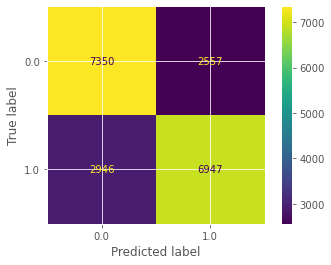

In [17]:
# Show confusion matrix
if is_test:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)
    
predictions = clf_top.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf_top.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_top.classes_)
disp.plot() 

if is_test:
    raise ValueError("Done")

In [18]:
# Compute Shapley values for explainability
encoded_x_train = pd.DataFrame(clf_top.named_steps['preprocessor'].fit_transform(X_train).todense())
encoded_x_test = pd.DataFrame(clf_top.named_steps['preprocessor'].fit_transform(X_test).todense())

explainer = shap.KernelExplainer(clf_top.steps[1][1].predict_proba, encoded_x_train.sample(100))
shap_values = explainer.shap_values(encoded_x_test.sample(10))

  0%|          | 0/10 [00:00<?, ?it/s]

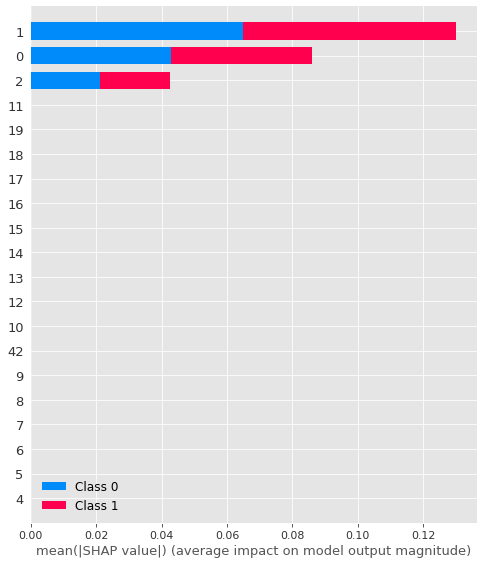

In [19]:
# Plot global explainability
shap.summary_plot(shap_values, encoded_x_test)

# From list earlier:
#  1 = Marked for PHT Program
#  0 = Hired through SMTP
#  2 = Religion (code) 

In [20]:
# Plot local explainability
shap.initjs()

shap.force_plot(explainer.expected_value[0], shap_values[0])

Feature: 0,	 Importance: 0.5234848484848484
Feature: 1,	 Importance: -0.6759974747474747
Feature: 2,	 Importance: -0.4452020202020202
Feature: 3,	 Importance: 0.14994949494949494
Feature: 4,	 Importance: 0.15295454545454545
Feature: 5,	 Importance: 0.18797979797979797
Feature: 6,	 Importance: 0.19130050505050505
Feature: 7,	 Importance: 0.042373737373737376
Feature: 8,	 Importance: 0.1166919191919192
Feature: 9,	 Importance: 0.1497979797979798
Feature: 10,	 Importance: 0.12402777777777778
Feature: 11,	 Importance: 0.0763888888888889
Feature: 12,	 Importance: 0.035833333333333335
Feature: 13,	 Importance: 0.013068181818181817
Feature: 14,	 Importance: 0.0052525252525252525
Feature: 15,	 Importance: 0.16237373737373736
Feature: 16,	 Importance: 0.0867929292929293
Feature: 17,	 Importance: 0.04782828282828283
Feature: 18,	 Importance: 0.026376262626262626
Feature: 19,	 Importance: 0.031313131313131314
Feature: 20,	 Importance: 0.057272727272727274
Feature: 21,	 Importance: 0.1045833333333

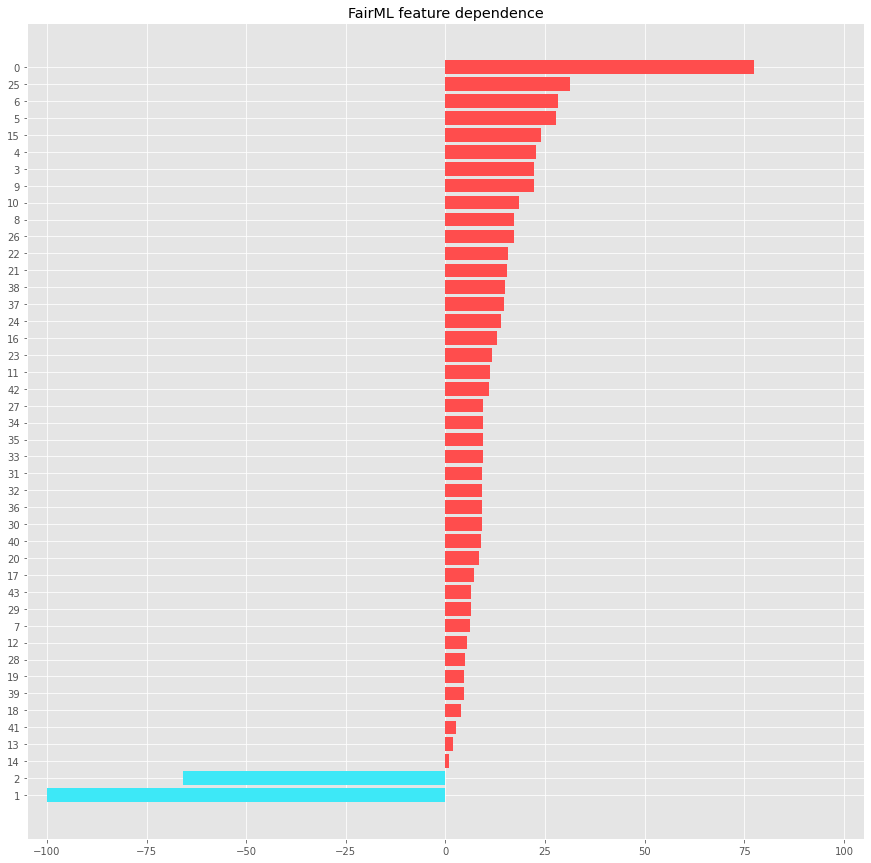

In [21]:
# Examine the bias

# Call audit model with model
total, _ = audit_model(clf_top.steps[1][1].predict, encoded_x_train)

# Print feature importance
print(total)

# Generate feature dependence plot
fig = plot_dependencies(
    total.median(),
    reverse_values=False,
    title="FairML feature dependence",
    fig_size = (15, 15)
)
plt.show()

# As in shap, the top 3 influencers are:
#  1 = Marked for PHT Program
#  0 = Hired through SMTP
#  2 = Religion (code) 

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[07:21:09] WARNING: ..\src\learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Best make_scorer(recall_score, average=binary): 0.710232218777431
Best Params: {'classifier': XGBClassifier(base_score=None, booster=None, colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, gamma=None,
              gpu_id=None, importance_type='gain', interaction_constraints=None,
              learning_rate=0.05, max_delta_step=None, max_depth=8,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=140, n_jobs=None, num_parallel_tree=None,
              random_state=None, reg_alpha=None, reg_lambda=None,
              scale_pos_weight=None, subsample=None, tree_method=None,
              use_lab

  0%|          | 0/10 [00:00<?, ?it/s]

Feature: 0,	 Importance: 0.47265151515151516
Feature: 1,	 Importance: 0.5528914141414142
Feature: 2,	 Importance: -0.5170833333333333
Feature: 3,	 Importance: 0.2290151515151515
Feature: 4,	 Importance: 0.22950757575757577
Feature: 5,	 Importance: 0.24214646464646464
Feature: 6,	 Importance: 0.2434848484848485
Feature: 7,	 Importance: 0.04031565656565657
Feature: 8,	 Importance: 0.10684343434343434
Feature: 9,	 Importance: 0.13920454545454544
Feature: 10,	 Importance: 0.11678030303030303
Feature: 11,	 Importance: 0.07246212121212121
Feature: 12,	 Importance: 0.03179292929292929
Feature: 13,	 Importance: 0.012184343434343435
Feature: 14,	 Importance: 0.004785353535353535
Feature: 15,	 Importance: 0.21398989898989898
Feature: 16,	 Importance: 0.11573232323232323
Feature: 17,	 Importance: 0.06392676767676768
Feature: 18,	 Importance: 0.03492424242424243
Feature: 19,	 Importance: 0.041212121212121214
Feature: 20,	 Importance: 0.06428030303030303
Feature: 21,	 Importance: 0.1175505050505050

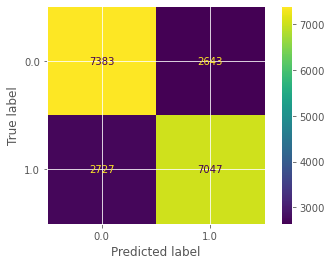

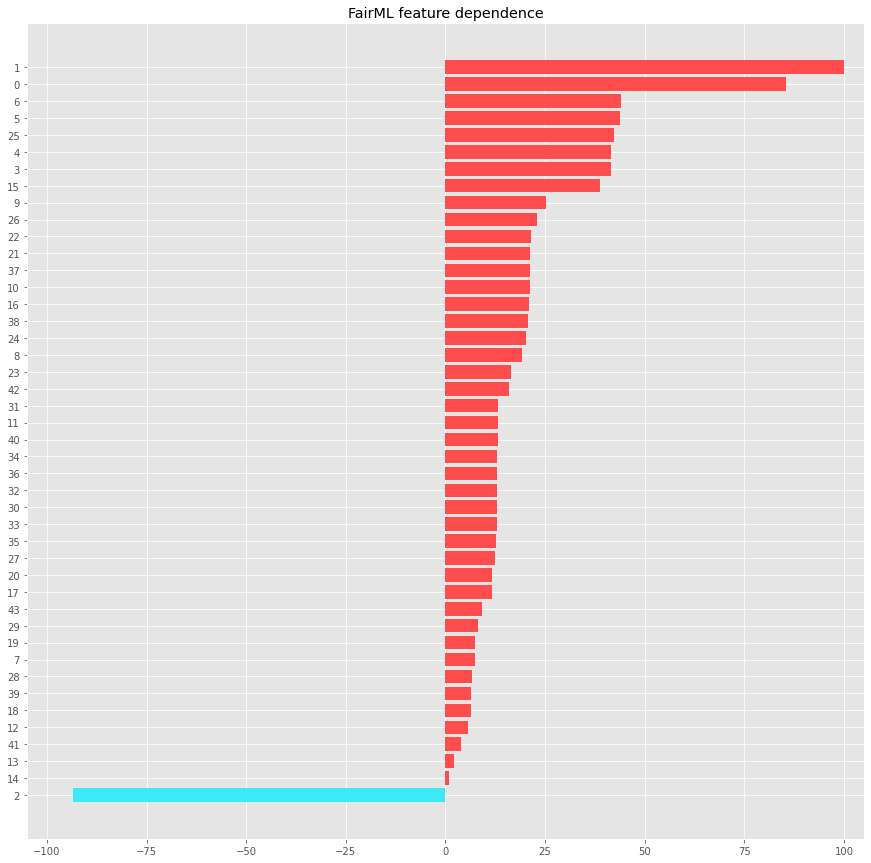

In [23]:
# Remove protected class bias (religion)
categorical_noprotected_features = ["Hired through SMTP", "Marked for PHT Program",
                        "Survey, Relative, Attitude toward Manager",
                        "Survey, Relative, Attitude toward Peers",
                        "Survey, Relative, Peer's Average Attitude toward Manager",
                        "Survey, Relative, Peer's Average Attitude toward WorkType",
                        "University"]

all_features = categorical_noprotected_features + numeric_features

numeric_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.nan, strategy = 'median')),
                                        ('scalar', StandardScaler())])

categorical_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
                                            ('ohe', OneHotEncoder(handle_unknown = 'ignore'))])

preprocessor = ColumnTransformer(transformers = [('num', numeric_transformer, numeric_features),
                                                 ('cat', categorical_transformer, categorical_noprotected_features)],
                                 remainder = 'drop')  # To remove biased columns

clf = Pipeline(steps = [('preprocessor', preprocessor), 
                        ('classifier', LogisticRegression())])  # Will be replaced later via grid search

# Fit classifier on new data configuration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)
fit_grid = grid.fit(X_train, y_train)
print(f"Best {fit_grid.scorer_}: {fit_grid.best_score_}\nBest Params: {fit_grid.best_params_}")
clf_top = grid.best_estimator_

    
scores = cross_validate(clf_top, X, y, scoring = 'recall')
print(f"Recall Score (unbiased): {np.mean(scores['test_score'])}")

# Show new confusion matrix
predictions = clf_top.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf_top.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_top.classes_)
disp.plot() 

# Show new shap
if is_test:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)
    
encoded_x_train = pd.DataFrame(clf_top.named_steps['preprocessor'].fit_transform(X_train).todense())
encoded_x_test = pd.DataFrame(clf_top.named_steps['preprocessor'].fit_transform(X_test).todense())

explainer = shap.KernelExplainer(clf_top.steps[1][1].predict_proba, encoded_x_train.sample(100))
shap_values = explainer.shap_values(encoded_x_test.sample(10))

from fairml import audit_model
from fairml import plot_dependencies

# Call audit model with model
total, _ = audit_model(clf_top.steps[1][1].predict, encoded_x_train)

# Print feature importance
print(total)

# Generate feature dependence plot
fig = plot_dependencies(
    total.median(),
    reverse_values=False,
    title="FairML feature dependence",
    fig_size = (15, 15)
)
plt.show()

# With religion gone, the top 3 influencers are now:
#  0 = Hired through SMTP
#  1 = Marked for PHT Program
#  2 = Survey, Relative, Attitude toward Manager 